In [8]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt
from sdv.metadata import Metadata
from sdv.single_table import GaussianCopulaSynthesizer

np.random.seed(29)

In [9]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [10]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [11]:
df = pd.concat([odroid1[:2000], odroid2[:2000], odroid3[:2000], odroid4[:2000], rpi4a[:2000], rpi8a[:2000], rpi8b[:2000], rpi8c[:2000], rpi8d[:2000]])
df = df.sample(frac=1).reset_index(drop=True)

In [12]:
len(df)

18000

In [13]:
model_hardening_data = df.head(6000)
intercepted_data = df.tail(12000)

In [14]:
model_hardening_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,odroid2,186.0,10.0,150.0,350.0,167.0,167.0,166.0
1,rpi-4a,16.2,17.4,1446.0,17.8,435.5,17.1,19.3
2,odroid1,165.0,167.0,167.0,168.0,169.0,166.0,168.0
3,odroid4,169.0,175.0,176.0,174.0,174.0,173.0,173.0
4,rpi-8c,24.9,629.1,16.7,2092.1,16.1,17.3,17.6
...,...,...,...,...,...,...,...,...
5995,odroid1,166.0,170.0,167.0,169.0,166.0,168.0,168.0
5996,odroid2,180.0,172.0,156.0,172.0,170.0,12.0,166.0
5997,odroid4,170.0,175.0,175.0,173.0,174.0,175.0,173.0
5998,rpi-4a,620.7,400.1,19.8,18.2,21.0,18.9,19.9


In [8]:
intercepted_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
10000,rpi-8a,433.3,13.5,15.3,216.3,216.6,199.9,216.5
10001,odroid2,164.0,183.0,167.0,166.0,166.0,167.0,183.0
10002,odroid4,171.0,173.0,173.0,173.0,171.0,172.0,173.0
10003,rpi-8b,225.4,231.9,232.7,233.2,434.0,16.0,434.1
10004,rpi-8d,15.9,18.2,75.9,1328.5,19.4,17.1,18.7
...,...,...,...,...,...,...,...,...
17995,rpi-8b,14.8,229.8,233.2,433.3,17.1,232.6,232.5
17996,rpi-8b,231.0,432.6,16.1,233.1,433.4,16.6,233.0
17997,rpi-8c,18.6,17.0,18.6,50.2,48.1,18.8,96.0
17998,odroid1,165.0,168.0,167.0,165.0,166.0,168.0,168.0


In [15]:
predictor = TabularPredictor.load("../models/classification")

In [16]:
metadata = Metadata.detect_from_dataframe(
    data=intercepted_data,
    table_name='intercepted_data')

# Simulation of attacker creating impersonation data

In [18]:
dists = ['norm', 'beta', 'truncnorm', 'uniform', 'gamma', 'gaussian_kde']
gaussian_results = pd.DataFrame(columns=['distribution', 'accuracy', 'balanced_accuracy', 'mcc'])

for dist in dists:
    print(dist)
    synthesizer = GaussianCopulaSynthesizer(metadata, default_distribution=dist)
    synthesizer.fit(intercepted_data)
    synthetic_data = synthesizer.sample(num_rows=1000)

    y_pred = predictor.predict(synthetic_data)
    y_pred_proba = predictor.predict_proba(synthetic_data)
    results = predictor.evaluate(synthetic_data)

    new_results = {'distribution':dist, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    gaussian_results.loc[len(gaussian_results)] = (new_results)

norm
beta
truncnorm
uniform
gamma
gaussian_kde


In [19]:
gaussian_results

,distribution,accuracy,balanced_accuracy,mcc
0,norm,0.117,0.107207,0.000102
1,beta,0.114,0.122113,0.012865
2,truncnorm,0.119,0.118837,0.010560
3,uniform,0.113,0.111753,0.002668
4,gamma,0.123,0.113454,0.003499
5,gaussian_kde,0.110,0.112834,0.002324


# Which devices are most vulnerable to this attack?

RPis seem to be more vulnerable overall, especially rpi-8c

In [20]:
devices_fooled = pd.DataFrame(columns=['device', 'accuracy'])
for device in list(y_pred.unique()):
    devices_fooled.loc[len(devices_fooled)] = {'device': device, 'accuracy': 0.0}

for pred, label in zip(list(y_pred), list(synthetic_data['label'])):
    if pred == label:
        devices_fooled.loc[devices_fooled['device'] == pred, 'accuracy'] += 1

for device in list(y_pred.unique()):
    devices_fooled.loc[devices_fooled['device'] == device, 'accuracy'] /= list(synthetic_data['label']).count(device)

devices_fooled['accuracy'] *= 100

<Axes: xlabel='device', ylabel='accuracy'>

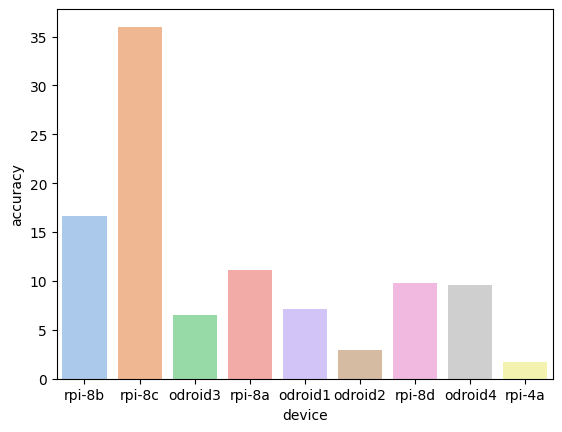

In [22]:
sns.barplot(data=devices_fooled, x='device', y='accuracy', hue='device', palette="pastel", legend=False, linewidth=2.5)

# How much synthetic data is required to train an anomaly detection model that can recognise synthetic data?

### Training data for anomaly detection model (based on first 75% training data)

In [24]:
synths_training = {}

dists = ['norm', 'beta', 'truncnorm', 'uniform', 'gamma', 'gaussian_kde']

# Train synthesisers on the first 75% of the train data for each distribution
for dist in dists:
    print(dist)
    synthesizer = GaussianCopulaSynthesizer(
        metadata, 
        default_distribution=dist
    )

    # Train the synthetic model using 75% of a train data. Holdout the rest for eval
    synthesizer.fit(model_hardening_data.head(4500))

    synths_training[dist] = synthesizer

norm
beta
truncnorm
uniform
gamma
gaussian_kde


In [37]:
abc = pd.DataFrame()
for dist in dists:
    abc = pd.concat([synths_training[dist].sample(num_rows=300), abc]) 

abc.to_csv('gaussian_copula_training.csv')

### Testing data which simulates an attacker trying to impersonate a node

In [27]:
synthetic_attack = pd.DataFrame()

dists = ['norm', 'beta', 'truncnorm', 'uniform', 'gamma', 'gaussian_kde']

# Train synthesisers on the last 25% of the train data for each distribution
for dist in dists:
    print(dist)
    synthesizer = GaussianCopulaSynthesizer(
        metadata, 
        default_distribution=dist
    )

    # synth trained using whole intercepted data df (reserved for the attackers use in our testing)
    synthesizer.fit(intercepted_data)

    synthetic_attack = pd.concat([synthetic_attack, synthesizer.sample(num_rows=250)])

norm
beta
truncnorm
uniform
gamma
gaussian_kde


In [36]:
# synthetic_attack.to_csv('gaussian_copula_attack (testing).csv')

### Data Flow

Overall we have 18k rows of IoT GPU ID data.
model_hardening_data = 4.5k
model_hardening_data - heldout = 1.5k
intercepted_data = 12k
This aligns with the test/train split of our original classification model. Our test/train data never overlaps

Our train dataset is made up of:
model_hardening_data (4.5k, genuine)
model_hardening_data (600-6k, imposter synthesised) -> synth norm(100-1000), synth beta(100-1000), synth truncnorm(100-1000), synth uniform(100-1000), synth gamma(100-1000), synth gaussian_kde(100-1000)

Our test dataset is made up of:
model_hardening_data - heldout (1.5k, genuine)
intercepted_data (12k used for training synth models, only 250 imposter rows generated per model) -> synth norm (250), synth beta (250), synth truncnorm (250), synth uniform (250), synth gamma (250), synth gaussian_kde (250)

In [28]:
results_df = pd.DataFrame(columns=['data_amount', 'accuracy', 'balanced_accuracy', 'mcc'])

dists = ['norm', 'beta', 'truncnorm', 'uniform', 'gamma', 'gaussian_kde']

# How much data do we need to accurately detect an impersonator?
for synthetic_data_amount in range(100, 1000, 100):
    print(f'Amount of data: {synthetic_data_amount}') 

    impersonator_df = pd.DataFrame()

    # create an impersonator df with synthetic_data_amount of data from each dist
    for dist in dists:
        impersonator_df = pd.concat([synths_training[dist].sample(num_rows=synthetic_data_amount), impersonator_df]) 
    
    impersonator_df['label'] = 'impersonator'

    genuine_df = model_hardening_data[:4500].copy()
    genuine_df['label'] = 'genuine'

    train_impersonator_df = pd.concat([impersonator_df, genuine_df])

    print(f'Length train df: {len(train_impersonator_df)}')

    impersonation_detector = TabularPredictor(label='label').fit(train_impersonator_df, num_gpus=1, presets='medium_quality', fit_weighted_ensemble=False)

    # # Create an eval dataset for the impersonation detector.
    # # Use the held out data from the train_set (reserved for model hardening), and some data from the test_set (reserved to simulate an attack)
    test_model_hardening = model_hardening_data.tail(1500).copy(deep=True)
    test_intercepted_data = synthetic_attack.copy(deep=True)
    test_model_hardening['label'] = 'genuine'
    test_intercepted_data['label'] = 'impersonator'

    test_impersonator_df = pd.concat([test_model_hardening, test_intercepted_data])

    print(f'Impersonator test df length: {len(test_impersonator_df)}')
    
    y_pred = impersonation_detector.predict(test_impersonator_df)
    y_pred_proba = impersonation_detector.predict_proba(test_impersonator_df)
    results = impersonation_detector.evaluate(test_impersonator_df)

    new_results = {'data_amount':synthetic_data_amount, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    results_df.loc[len(results_df)] = (new_results)


Amount of data: 100


No path specified. Models will be saved in: "AutogluonModels\ag-20250327_014313"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       55.78 GB / 63.72 GB (87.5%)
Disk Space Avail:   966.74 GB / 1906.98 GB (50.7%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 2 - Spoofing Attack Detection\AutogluonModels\ag-20250327_014313"
Train Data Rows:    5100
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['impersonator', 'genuine']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may

Length train df: 5100


	0.9902	 = Validation score   (accuracy)
	3.52s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9882	 = Validation score   (accuracy)
	1.39s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9843	 = Validation score   (accuracy)
	0.38s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9843	 = Validation score   (accuracy)
	0.37s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9902	 = Validation score   (accurac

Impersonator test df length: 3000
Amount of data: 200


...

Impersonator test df length: 3000
Amount of data: 900


No path specified. Models will be saved in: "AutogluonModels\ag-20250327_015033"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       55.16 GB / 63.72 GB (86.6%)
Disk Space Avail:   965.86 GB / 1906.98 GB (50.6%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 2 - Spoofing Attack Detection\AutogluonModels\ag-20250327_015033"
Train Data Rows:    9900
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['impersonator', 'genuine']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may

Length train df: 9900


	0.9929	 = Validation score   (accuracy)
	2.99s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.996	 = Validation score   (accuracy)
	2.53s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9929	 = Validation score   (accuracy)
	0.43s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9929	 = Validation score   (accuracy)
	0.43s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9919	 = Validation score   (accuracy

Impersonator test df length: 3000


In [34]:
impersonation_detector.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBM,0.995960,accuracy,0.006961,2.531260,0.006961,2.531260,1,True,4
1,LightGBMLarge,0.995960,accuracy,0.008508,7.591349,0.008508,7.591349,1,True,12
2,XGBoost,0.993939,accuracy,0.004935,1.164230,0.004935,1.164230,1,True,10
3,LightGBMXT,0.992929,accuracy,0.012153,2.986723,0.012153,2.986723,1,True,3
4,RandomForestGini,0.992929,accuracy,0.042624,0.429943,0.042624,0.429943,1,True,5
5,RandomForestEntr,0.992929,accuracy,0.043876,0.426896,0.043876,0.426896,1,True,6
6,ExtraTreesEntr,0.991919,accuracy,0.043343,0.354192,0.043343,0.354192,1,True,8
7,ExtraTreesGini,0.991919,accuracy,0.043999,0.379083,0.043999,0.379083,1,True,7
8,NeuralNetTorch,0.988889,accuracy,0.015487,43.216944,0.015487,43.216944,1,True,11
9,NeuralNetFastAI,0.968687,accuracy,0.000000,4.174011,0.000000,4.174011,1,True,9


In [35]:
results

{'accuracy': 0.989,
 'balanced_accuracy': np.float64(0.989),
 'mcc': np.float64(0.978001956005868),
 'roc_auc': np.float64(0.9996013333333333),
 'f1': np.float64(0.989010989010989),
 'precision': np.float64(0.9880239520958084),
 'recall': np.float64(0.99)}

# Anomaly Detection Model

Just 300 rows of synthetic training data for each synthetic distribution is enough to determine synthetic data from real data, with >98% accuracy.

<Axes: xlabel='data_amount', ylabel='value'>

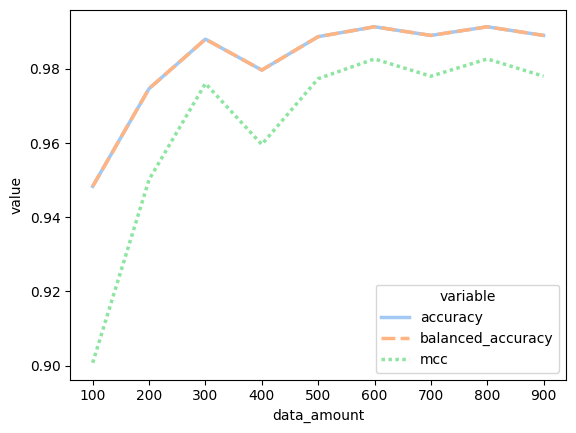

In [29]:
sns.lineplot(data=pd.melt(results_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)